# Named Entity Recognition in Noisy Social Media Text

## Goal

This notebook fine-tunes a Transformer model to identify named entities in noisy user-generated text.

Unlike document classification, Named Entity Recognition assigns a label to every word.

## Entity categories

The dataset contains six entity types:

- corporation
- creative work
- group
- location
- person
- product

## BIO tagging

Each token receives a BIO label:

- `B-type`: beginning of an entity
- `I-type`: continuation of the same entity
- `O`: not part of an entity

For example:

| Token | Label |
|---|---|
| Empire | B-location |
| State | I-location |
| Building | I-location |
| opened | O |
| today | O |

## Main experiments

- Inspect entity imbalance
- Build an all-`O` majority baseline
- Align word-level labels with Transformer subwords
- Fine-tune DistilBERT for token classification
- Evaluate exact entity spans using precision, recall, and F1
- Analyse performance by entity type
- Separate boundary errors from entity-type errors
- Analyse prediction confidence
- Test sensitivity to removing capitalisation
- Extract entities from custom text

## Main question

Can a pretrained language model recognise rare and emerging entities in noisy text while identifying both the correct entity type and the exact entity boundaries?

In [3]:
import copy
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    get_linear_schedule_with_warmup
)

from seqeval.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
MODEL_NAME = "distilbert-base-cased"

MAX_LENGTH = 128
BATCH_SIZE = 16
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 0.01
TRAINING_EPOCHS = 3


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_STATE)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)
print("PyTorch version:", torch.__version__)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


Device: cuda
PyTorch version: 2.5.1+cu124


In [4]:
try:
    raw_dataset = load_dataset(
        "wnut_17"
    )

except Exception as first_error:
    print(
        "Default loader failed. "
        "Trying the Parquet conversion."
    )

    print(
        "Original error:",
        str(first_error)[:300]
    )

    raw_dataset = load_dataset(
        "flaitenberger/wnut_17"
    )

raw_dataset

README.md: 0.00B [00:00, ?B/s]

wnut_17.py: 0.00B [00:00, ?B/s]

Default loader failed. Trying the Parquet conversion.
Original error: Dataset scripts are no longer supported, but found wnut_17.py


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


...

data/test-00000-of-00001.parquet:   0%|          | 0.00/115k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3394 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1009 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1287 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 3394
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 1009
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 1287
    })
})

In [5]:
for split_name, split_data in (
    raw_dataset.items()
):
    print(
        split_name,
        len(split_data)
    )

train 3394
validation 1009
test 1287


In [6]:
ner_feature = (
    raw_dataset["train"]
    .features["ner_tags"]
    .feature
)

if hasattr(ner_feature, "names"):
    label_list = list(
        ner_feature.names
    )
else:
    label_list = [
        "O",
        "B-corporation",
        "I-corporation",
        "B-creative-work",
        "I-creative-work",
        "B-group",
        "I-group",
        "B-location",
        "I-location",
        "B-person",
        "I-person",
        "B-product",
        "I-product"
    ]

number_of_labels = len(label_list)

id2label = {
    index: label
    for index, label
    in enumerate(label_list)
}

label2id = {
    label: index
    for index, label
    in enumerate(label_list)
}

print("Number of BIO labels:", number_of_labels)
print(label_list)

Number of BIO labels: 13
['O', 'B-corporation', 'I-corporation', 'B-creative-work', 'I-creative-work', 'B-group', 'I-group', 'B-location', 'I-location', 'B-person', 'I-person', 'B-product', 'I-product']


## Data loading 

The WNUT 17 dataset contained:

- 3,394 training sentences
- 1,009 validation sentences
- 1,287 test sentences

The dataset used six semantic entity categories:

- corporation
- creative work
- group
- location
- person
- product

These categories were represented using thirteen BIO labels:

- one `O` label
- six `B-type` labels
- six `I-type` labels

The default Hugging Face dataset script could not be loaded because dataset scripts were no longer supported in the installed library version. The notebook successfully used the Parquet version of the dataset instead.

In [7]:
example = raw_dataset["train"][0]

example_tokens = example["tokens"]

example_labels = [
    label_list[label_id]
    for label_id in example["ner_tags"]
]

example_df = pd.DataFrame({
    "token": example_tokens,
    "label": example_labels
})

example_df

,token,label
0,@paulwalk,O
1,It,O
2,'s,O
3,the,O
4,view,O
5,from,O
6,where,O
7,I,O
8,'m,O
9,living,O


In [8]:
print(
    " ".join(example_tokens)
)

@paulwalk It 's the view from where I 'm living for two weeks . Empire State Building = ESB . Pretty bad storm here last evening .


## BIO example 

The first training example contained two location entities:

- `Empire State Building`
- `ESB`

The first entity was represented using:

- `Empire` → `B-location`
- `State` → `I-location`
- `Building` → `I-location`

`ESB` was a separate location entity and therefore received another `B-location` label.

This demonstrates that a multi-word entity begins with a `B-type` label and continues through one or more `I-type` labels. A new entity must begin with another `B-type` label, even when it has the same semantic category as the previous entity.

In [9]:
bio_label_counts = Counter()

for sentence_labels in (
    raw_dataset["train"]["ner_tags"]
):
    for label_id in sentence_labels:
        bio_label_counts[
            label_list[label_id]
        ] += 1

bio_distribution_df = pd.DataFrame([
    {
        "label": label,
        "tokens": bio_label_counts[label]
    }
    for label in label_list
])

bio_distribution_df

,label,tokens
0,O,59570
1,B-corporation,221
2,I-corporation,46
3,B-creative-work,140
4,I-creative-work,206
5,B-group,264
6,I-group,150
7,B-location,548
8,I-location,245
9,B-person,660


In [10]:
entity_token_counts = Counter()

for label, count in (
    bio_label_counts.items()
):
    if label == "O":
        continue

    entity_type = label.split(
        "-",
        maxsplit=1
    )[1]

    entity_token_counts[
        entity_type
    ] += count

entity_distribution_df = (
    pd.DataFrame([
        {
            "entity_type": entity_type,
            "entity_tokens": count
        }
        for entity_type, count
        in entity_token_counts.items()
    ])
    .sort_values(
        "entity_tokens",
        ascending=False
    )
    .reset_index(drop=True)
)

entity_distribution_df

,entity_type,entity_tokens
0,person,995
1,location,793
2,group,414
3,creative-work,346
4,product,345
5,corporation,267


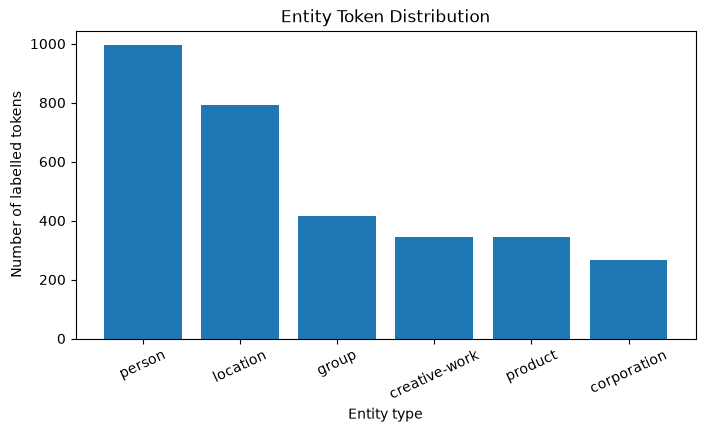

In [11]:
plt.figure(figsize=(8, 4))

plt.bar(
    entity_distribution_df[
        "entity_type"
    ],
    entity_distribution_df[
        "entity_tokens"
    ]
)

plt.title(
    "Entity Token Distribution"
)

plt.xlabel("Entity type")
plt.ylabel("Number of labelled tokens")
plt.xticks(rotation=25)
plt.show()

In [12]:
total_training_tokens = sum(
    bio_label_counts.values()
)

outside_tokens = bio_label_counts["O"]

print(
    "Total training tokens:",
    total_training_tokens
)

print(
    "O-label percentage:",
    round(
        outside_tokens
        / total_training_tokens
        * 100,
        2
    )
)

Total training tokens: 62730
O-label percentage: 94.96


## Label imbalance 

The training data contained 62,730 original word tokens.

Of these, 59,570 were labelled `O`, meaning that 94.96% of all training tokens were not part of a named entity.

Entity-token counts were:

| Entity type | Labelled tokens |
|---|---:|
| Person | 995 |
| Location | 793 |
| Group | 414 |
| Creative work | 346 |
| Product | 345 |
| Corporation | 267 |

Person was the most frequent entity category, while corporation was the least frequent.

This was an extremely imbalanced token-classification problem. A model could obtain high token accuracy by predicting `O` for nearly every word while extracting few or no useful entities.

Entity-level precision, recall, and F1-score were therefore more informative than token accuracy.

In [13]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print(
    "Tokenizer:",
    tokenizer.__class__.__name__
)

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: BertTokenizer


In [14]:
tokenised_example = tokenizer(
    example_tokens,
    is_split_into_words=True
)

subword_tokens = tokenizer.convert_ids_to_tokens(
    tokenised_example["input_ids"]
)

word_ids = tokenised_example.word_ids()

alignment_example_df = pd.DataFrame({
    "subword_token": subword_tokens,
    "original_word_id": word_ids
})

alignment_example_df.head(30)

,subword_token,original_word_id
0,[CLS],NaN
1,@,0.0
2,p,0.0
3,##aul,0.0
4,##walk,0.0
5,It,1.0
6,',2.0
7,s,2.0
8,the,3.0
9,view,4.0


## Subword tokenisation 

The cased DistilBERT tokenizer divided several original words into multiple subword tokens.

For example:

- `@paulwalk` became `@`, `p`, `##aul`, and `##walk`
- `ESB` became `E` and `##SB`

The dataset provided only one BIO label for each original word.

During alignment:

- the first subword received the word's BIO label
- later subwords received `-100`
- special tokens such as `[CLS]` and `[SEP]` also received `-100`

For example, `E` received `B-location`, while `##SB` was ignored during loss calculation.

This prevented one original entity label from being counted multiple times merely because the tokenizer split its word into several pieces.

In [15]:
def tokenize_and_align_labels(
    examples
):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        max_length=MAX_LENGTH,
        is_split_into_words=True
    )

    aligned_label_batches = []

    for batch_index, word_labels in enumerate(
        examples["ner_tags"]
    ):
        word_ids = tokenized_inputs.word_ids(
            batch_index=batch_index
        )

        previous_word_id = None
        aligned_labels = []

        for word_id in word_ids:
            if word_id is None:
                aligned_labels.append(-100)

            elif word_id != previous_word_id:
                aligned_labels.append(
                    word_labels[word_id]
                )

            else:
                aligned_labels.append(-100)

            previous_word_id = word_id

        aligned_label_batches.append(
            aligned_labels
        )

    tokenized_inputs["labels"] = (
        aligned_label_batches
    )

    return tokenized_inputs

In [16]:
tokenized_dataset = raw_dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=
        raw_dataset["train"].column_names
)

tokenized_dataset

Map:   0%|          | 0/3394 [00:00<?, ? examples/s]

Map:   0%|          | 0/1009 [00:00<?, ? examples/s]

Map:   0%|          | 0/1287 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3394
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1009
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1287
    })
})

In [17]:
aligned_example = (
    tokenized_dataset["train"][0]
)

aligned_tokens = tokenizer.convert_ids_to_tokens(
    aligned_example["input_ids"]
)

aligned_labels = [
    (
        "IGNORED"
        if label_id == -100
        else label_list[label_id]
    )
    for label_id in aligned_example["labels"]
]

pd.DataFrame({
    "token": aligned_tokens,
    "training_label": aligned_labels
}).head(35)

,token,training_label
0,[CLS],IGNORED
1,@,O
2,p,IGNORED
3,##aul,IGNORED
4,##walk,IGNORED
5,It,O
6,',O
7,s,IGNORED
8,the,O
9,view,O


In [18]:
data_collator = (
    DataCollatorForTokenClassification(
        tokenizer=tokenizer
    )
)

In [19]:
training_loader = DataLoader(
    tokenized_dataset["train"],
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    tokenized_dataset["validation"],
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    tokenized_dataset["test"],
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator,
    pin_memory=torch.cuda.is_available()
)

print(
    "Training batches:",
    len(training_loader)
)

print(
    "Validation batches:",
    len(validation_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Training batches: 213
Validation batches: 64
Test batches: 81


In [20]:
def calculate_sequence_metrics(
    true_sequences,
    predicted_sequences
):
    return {
        "precision": precision_score(
            true_sequences,
            predicted_sequences,
            zero_division=0
        ),
        "recall": recall_score(
            true_sequences,
            predicted_sequences,
            zero_division=0
        ),
        "f1": f1_score(
            true_sequences,
            predicted_sequences,
            zero_division=0
        ),
        "token_accuracy": accuracy_score(
            true_sequences,
            predicted_sequences
        )
    }

In [21]:
@torch.no_grad()
def evaluate_ner_model(
    model,
    data_loader
):
    model.eval()

    losses = []

    true_sequences = []
    predicted_sequences = []
    confidence_sequences = []

    for batch in data_loader:
        labels_cpu = (
            batch["labels"]
            .detach()
            .cpu()
            .numpy()
        )

        batch = {
            key: value.to(device)
            for key, value
            in batch.items()
        }

        outputs = model(**batch)

        losses.append(
            outputs.loss.item()
        )

        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )

        predictions = probabilities.argmax(
            dim=-1
        )

        prediction_confidences = (
            probabilities.max(dim=-1).values
        )

        predictions_cpu = (
            predictions
            .detach()
            .cpu()
            .numpy()
        )

        confidences_cpu = (
            prediction_confidences
            .detach()
            .cpu()
            .numpy()
        )

        for (
            predicted_ids,
            true_ids,
            token_confidences
        ) in zip(
            predictions_cpu,
            labels_cpu,
            confidences_cpu
        ):
            sentence_true = []
            sentence_predicted = []
            sentence_confidences = []

            for (
                predicted_id,
                true_id,
                confidence
            ) in zip(
                predicted_ids,
                true_ids,
                token_confidences
            ):
                if true_id == -100:
                    continue

                sentence_true.append(
                    label_list[int(true_id)]
                )

                sentence_predicted.append(
                    label_list[
                        int(predicted_id)
                    ]
                )

                sentence_confidences.append(
                    float(confidence)
                )

            true_sequences.append(
                sentence_true
            )

            predicted_sequences.append(
                sentence_predicted
            )

            confidence_sequences.append(
                sentence_confidences
            )

    metrics = calculate_sequence_metrics(
        true_sequences,
        predicted_sequences
    )

    metrics["loss"] = float(
        np.mean(losses)
    )

    return {
        "metrics": metrics,
        "true_sequences":
            true_sequences,
        "predicted_sequences":
            predicted_sequences,
        "confidence_sequences":
            confidence_sequences
    }

In [22]:
baseline_true_sequences = [
    [
        label_list[label_id]
        for label_id
        in sentence_labels
    ]
    for sentence_labels
    in raw_dataset["test"]["ner_tags"]
]

baseline_predicted_sequences = [
    ["O"] * len(sentence_labels)
    for sentence_labels
    in baseline_true_sequences
]

baseline_metrics = (
    calculate_sequence_metrics(
        baseline_true_sequences,
        baseline_predicted_sequences
    )
)

baseline_metrics

{'precision': np.float64(0.0),
 'recall': np.float64(0.0),
 'f1': np.float64(0.0),
 'token_accuracy': 0.9256219543472686}

## Majority baseline 

The all-`O` baseline achieved:

- Entity precision: 0.0000
- Entity recall: 0.0000
- Entity F1-score: 0.0000
- Token accuracy: 0.9256

The baseline correctly labelled most non-entity words because the test data was dominated by `O` tokens.

However, it never predicted an entity and therefore had zero entity-level precision, recall, and F1-score.

This demonstrates why token accuracy is misleading for highly imbalanced Named Entity Recognition. A token accuracy above 92% did not represent useful entity extraction.

In [23]:
model = (
    AutoModelForTokenClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=number_of_labels,
        id2label=id2label,
        label2id=label2id
    )
    .to(device)
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 65,200,909


In [24]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

total_training_steps = (
    TRAINING_EPOCHS
    * len(training_loader)
)

warmup_steps = int(
    0.10 * total_training_steps
)

scheduler = (
    get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=
            total_training_steps
    )
)

print(
    "Total training steps:",
    total_training_steps
)

print(
    "Warmup steps:",
    warmup_steps
)

Total training steps: 639
Warmup steps: 63


In [25]:
history_rows = []

best_validation_f1 = -np.inf
best_model_state = None

In [26]:
for epoch in range(
    1,
    TRAINING_EPOCHS + 1
):
    model.train()

    training_losses = []

    for batch in training_loader:
        batch = {
            key: value.to(device)
            for key, value
            in batch.items()
        }

        optimizer.zero_grad()

        outputs = model(**batch)

        loss = outputs.loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        scheduler.step()

        training_losses.append(
            loss.item()
        )

    validation_result = (
        evaluate_ner_model(
            model,
            validation_loader
        )
    )

    validation_metrics = (
        validation_result["metrics"]
    )

    mean_training_loss = float(
        np.mean(training_losses)
    )

    history_rows.append({
        "epoch": epoch,
        "training_loss":
            mean_training_loss,
        "validation_loss":
            validation_metrics["loss"],
        "validation_precision":
            validation_metrics["precision"],
        "validation_recall":
            validation_metrics["recall"],
        "validation_f1":
            validation_metrics["f1"],
        "validation_token_accuracy":
            validation_metrics[
                "token_accuracy"
            ]
    })

    print(
        f"Epoch {epoch} | "
        f"Train loss "
        f"{mean_training_loss:.4f} | "
        f"Val loss "
        f"{validation_metrics['loss']:.4f} | "
        f"Val precision "
        f"{validation_metrics['precision']:.4f} | "
        f"Val recall "
        f"{validation_metrics['recall']:.4f} | "
        f"Val F1 "
        f"{validation_metrics['f1']:.4f}"
    )

    if (
        validation_metrics["f1"]
        > best_validation_f1
    ):
        best_validation_f1 = (
            validation_metrics["f1"]
        )

        best_model_state = {
            key:
                value.detach().cpu().clone()
            for key, value
            in model.state_dict().items()
        }

Epoch 1 | Train loss 0.4550 | Val loss 0.2496 | Val precision 0.6184 | Val recall 0.3624 | Val F1 0.4570
Epoch 2 | Train loss 0.1102 | Val loss 0.2203 | Val precision 0.6182 | Val recall 0.4222 | Val F1 0.5018
Epoch 3 | Train loss 0.0666 | Val loss 0.2256 | Val precision 0.5994 | Val recall 0.4474 | Val F1 0.5123


In [27]:
if best_model_state is not None:
    model.load_state_dict(
        best_model_state
    )

model = model.to(device)

training_history = pd.DataFrame(
    history_rows
)

training_history

,epoch,training_loss,validation_loss,validation_precision,validation_recall,validation_f1,validation_token_accuracy
0,1,0.455045,0.249642,0.618367,0.362440,0.457014,0.942033
1,2,0.110172,0.220333,0.618214,0.422249,0.501777,0.949024
2,3,0.066584,0.225582,0.599359,0.447368,0.512329,0.950168


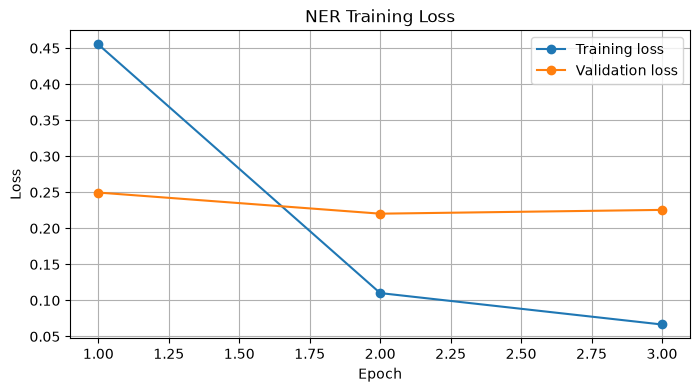

In [28]:
plt.figure(figsize=(8, 4))

plt.plot(
    training_history["epoch"],
    training_history["training_loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    training_history["epoch"],
    training_history["validation_loss"],
    marker="o",
    label="Validation loss"
)

plt.title("NER Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

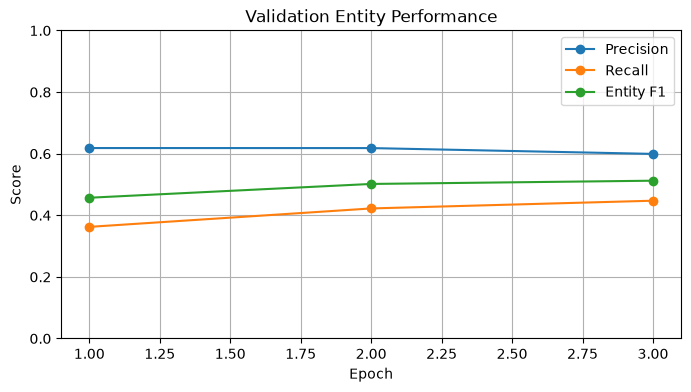

In [29]:
plt.figure(figsize=(8, 4))

plt.plot(
    training_history["epoch"],
    training_history["validation_precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    training_history["epoch"],
    training_history["validation_recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    training_history["epoch"],
    training_history["validation_f1"],
    marker="o",
    label="Entity F1"
)

plt.title("Validation Entity Performance")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

## Training behaviour 

The model was fine-tuned for three epochs using 639 total optimisation steps and 63 warm-up steps.

Training loss decreased rapidly:

| Epoch | Training loss | Validation loss | Precision | Recall | Entity F1 |
|---:|---:|---:|---:|---:|---:|
| 1 | 0.4550 | 0.2496 | 0.6184 | 0.3624 | 0.4570 |
| 2 | 0.1102 | 0.2203 | 0.6182 | 0.4222 | 0.5018 |
| 3 | 0.0666 | 0.2256 | 0.5994 | 0.4474 | 0.5123 |

Most learning occurred during the first two epochs.

Validation recall improved consistently from 0.3624 to 0.4474. Precision remained near 0.62 for the first two epochs before falling slightly to 0.5994.

The highest validation entity F1-score was 0.5123 at Epoch 3, so the Epoch 3 checkpoint was retained.

Validation loss fell through Epoch 2 and then increased slightly during Epoch 3. This suggests the beginning of overfitting, even though entity F1 continued improving because recall increased.

In [30]:
test_result = evaluate_ner_model(
    model,
    test_loader
)

test_metrics = test_result["metrics"]

pd.DataFrame({
    "metric": list(test_metrics.keys()),
    "value": list(test_metrics.values())
})

,metric,value
0,precision,0.516529
1,recall,0.348189
2,f1,0.415973
3,token_accuracy,0.944701
4,loss,0.275733


In [31]:
test_report_text = classification_report(
    test_result["true_sequences"],
    test_result["predicted_sequences"],
    digits=4,
    zero_division=0
)

print(test_report_text)

               precision    recall  f1-score   support

  corporation     0.1429    0.1212    0.1311        66
creative-work     0.4773    0.1489    0.2270       141
        group     0.3671    0.1758    0.2377       165
     location     0.4471    0.5067    0.4750       150
       person     0.6979    0.5397    0.6087       428
      product     0.2174    0.0787    0.1156       127

    micro avg     0.5165    0.3482    0.4160      1077
    macro avg     0.3916    0.2618    0.2992      1077
 weighted avg     0.4927    0.3482    0.3959      1077



## Final test results 

The final DistilBERT model achieved:

- Entity precision: 0.5165
- Entity recall: 0.3482
- Entity F1-score: 0.4160
- Token accuracy: 0.9447
- Test loss: 0.2757

Compared with the all-`O` baseline:

| Model | Token accuracy | Entity F1 |
|---|---:|---:|
| All-O baseline | 0.9256 | 0.0000 |
| DistilBERT NER | 0.9447 | 0.4160 |

Token accuracy increased by only about 1.91 percentage points, but entity F1 increased from zero to 0.4160. This further demonstrates that entity-level evaluation captures improvements that token accuracy can hide.

Precision was substantially higher than recall:

- Precision: 0.5165
- Recall: 0.3482

The model was therefore relatively conservative. When it predicted a complete entity span, it was correct slightly more than half the time, but it failed to retrieve many annotated entities.

Test F1 was approximately 0.096 lower than the best validation F1, indicating that performance did not transfer fully to the test examples.

In [32]:
test_report_dict = classification_report(
    test_result["true_sequences"],
    test_result["predicted_sequences"],
    output_dict=True,
    zero_division=0
)

entity_types = [
    "corporation",
    "creative-work",
    "group",
    "location",
    "person",
    "product"
]

entity_performance_rows = []

for entity_type in entity_types:
    entity_metrics = test_report_dict.get(
        entity_type,
        {}
    )

    entity_performance_rows.append({
        "entity_type": entity_type,
        "precision":
            entity_metrics.get(
                "precision",
                np.nan
            ),
        "recall":
            entity_metrics.get(
                "recall",
                np.nan
            ),
        "f1":
            entity_metrics.get(
                "f1-score",
                np.nan
            ),
        "support":
            entity_metrics.get(
                "support",
                0
            )
    })

entity_performance_df = (
    pd.DataFrame(
        entity_performance_rows
    )
    .sort_values(
        "f1",
        ascending=False
    )
    .reset_index(drop=True)
)

entity_performance_df

,entity_type,precision,recall,f1,support
0,person,0.697885,0.539720,0.608696,428
1,location,0.447059,0.506667,0.475000,150
2,group,0.367089,0.175758,0.237705,165
3,creative-work,0.477273,0.148936,0.227027,141
4,corporation,0.142857,0.121212,0.131148,66
5,product,0.217391,0.078740,0.115607,127


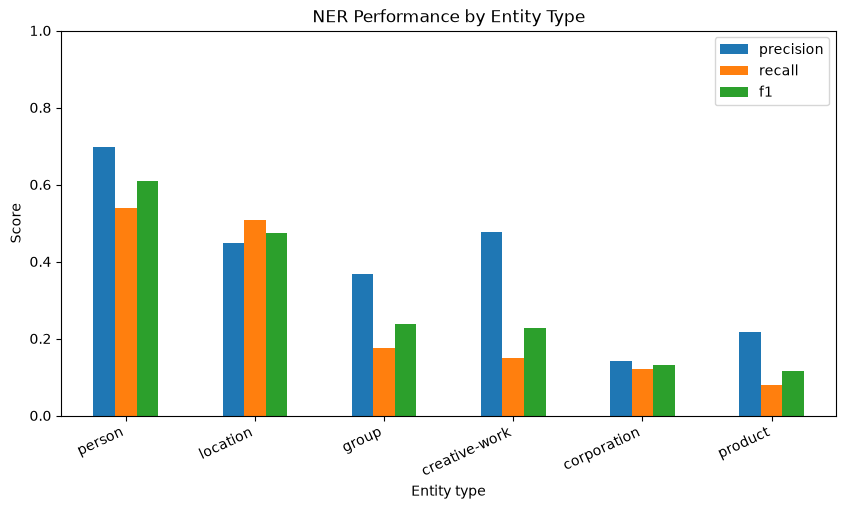

In [33]:
entity_performance_df.set_index(
    "entity_type"
)[
    ["precision", "recall", "f1"]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("NER Performance by Entity Type")
plt.xlabel("Entity type")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.show()

## Entity-type performance 

Entity-level performance differed substantially across categories.

| Entity type | Precision | Recall | F1-score | Test support |
|---|---:|---:|---:|---:|
| Person | 0.6979 | 0.5397 | 0.6087 | 428 |
| Location | 0.4471 | 0.5067 | 0.4750 | 150 |
| Group | 0.3671 | 0.1758 | 0.2377 | 165 |
| Creative work | 0.4773 | 0.1489 | 0.2270 | 141 |
| Corporation | 0.1429 | 0.1212 | 0.1311 | 66 |
| Product | 0.2174 | 0.0787 | 0.1156 | 127 |

Person was the strongest category, with an F1-score of 0.6087. It had both the largest test support and the highest precision.

Location was the second-strongest category. It was the only category for which recall was higher than precision, meaning the model detected many locations but also produced a noticeable number of false location predictions.

Product was the weakest category, with recall of only 0.0787 and F1 of 0.1156.

Corporation was the rarest training category, but product performed even worse. This shows that frequency was not the only factor. Products and creative works also have highly variable names and can resemble ordinary words, making them especially difficult to identify from context.

In [34]:
def bio_labels_to_spans(
    tokens,
    labels
):
    spans = []

    current_start = None
    current_type = None

    extended_labels = list(labels) + ["O"]

    for index, label in enumerate(
        extended_labels
    ):
        if label == "O":
            if current_type is not None:
                spans.append({
                    "start": current_start,
                    "end": index,
                    "entity_type":
                        current_type,
                    "text": " ".join(
                        tokens[
                            current_start:index
                        ]
                    )
                })

                current_start = None
                current_type = None

            continue

        prefix, entity_type = label.split(
            "-",
            maxsplit=1
        )

        starts_new_entity = (
            prefix == "B"
            or current_type != entity_type
        )

        if starts_new_entity:
            if current_type is not None:
                spans.append({
                    "start": current_start,
                    "end": index,
                    "entity_type":
                        current_type,
                    "text": " ".join(
                        tokens[
                            current_start:index
                        ]
                    )
                })

            current_start = index
            current_type = entity_type

    return spans

In [35]:
example_index = 0

example_test_tokens = (
    raw_dataset["test"][
        example_index
    ]["tokens"]
)

number_of_predicted_words = len(
    test_result[
        "predicted_sequences"
    ][example_index]
)

example_test_tokens = (
    example_test_tokens[
        :number_of_predicted_words
    ]
)

true_spans = bio_labels_to_spans(
    example_test_tokens,
    test_result[
        "true_sequences"
    ][example_index]
)

predicted_spans = bio_labels_to_spans(
    example_test_tokens,
    test_result[
        "predicted_sequences"
    ][example_index]
)

print(
    "Sentence:",
    " ".join(example_test_tokens)
)

print("\nTrue entities:")
display(pd.DataFrame(true_spans))

print("\nPredicted entities:")
display(pd.DataFrame(predicted_spans))

Sentence: & gt ; * The soldier was killed when another avalanche hit an army barracks in the northern area of Sonmarg , said a military spokesman .

True entities:


,start,end,entity_type,text
0,20,21,location,Sonmarg



Predicted entities:


,start,end,entity_type,text
0,20,21,location,Sonmarg


In [37]:
def spans_overlap(
    first_span,
    second_span
):
    return (
        first_span["start"]
        < second_span["end"]
        and second_span["start"]
        < first_span["end"]
    )

In [38]:
def analyse_span_errors(
    raw_split,
    true_sequences,
    predicted_sequences
):
    error_rows = []

    for sentence_index, (
        true_labels,
        predicted_labels
    ) in enumerate(
        zip(
            true_sequences,
            predicted_sequences
        )
    ):
        tokens = raw_split[
            sentence_index
        ]["tokens"][:len(true_labels)]

        true_spans = bio_labels_to_spans(
            tokens,
            true_labels
        )

        predicted_spans = (
            bio_labels_to_spans(
                tokens,
                predicted_labels
            )
        )

        for true_span in true_spans:
            exact_matches = [
                predicted_span
                for predicted_span
                in predicted_spans
                if (
                    predicted_span["start"]
                    == true_span["start"]
                    and predicted_span["end"]
                    == true_span["end"]
                    and predicted_span[
                        "entity_type"
                    ]
                    == true_span[
                        "entity_type"
                    ]
                )
            ]

            if exact_matches:
                continue

            overlapping_predictions = [
                predicted_span
                for predicted_span
                in predicted_spans
                if spans_overlap(
                    true_span,
                    predicted_span
                )
            ]

            if not overlapping_predictions:
                error_type = "Missed entity"
                matched_prediction = None

            else:
                matched_prediction = max(
                    overlapping_predictions,
                    key=lambda span:
                        min(
                            true_span["end"],
                            span["end"]
                        )
                        - max(
                            true_span["start"],
                            span["start"]
                        )
                )

                same_boundaries = (
                    matched_prediction["start"]
                    == true_span["start"]
                    and matched_prediction["end"]
                    == true_span["end"]
                )

                same_type = (
                    matched_prediction[
                        "entity_type"
                    ]
                    == true_span[
                        "entity_type"
                    ]
                )

                if same_boundaries:
                    error_type = (
                        "Wrong entity type"
                    )

                elif same_type:
                    error_type = (
                        "Boundary error"
                    )

                else:
                    error_type = (
                        "Boundary and type error"
                    )

            error_rows.append({
                "sentence_index":
                    sentence_index,
                "error_type":
                    error_type,
                "true_text":
                    true_span["text"],
                "true_type":
                    true_span["entity_type"],
                "predicted_text":
                    (
                        None
                        if matched_prediction
                        is None
                        else matched_prediction[
                            "text"
                        ]
                    ),
                "predicted_type":
                    (
                        None
                        if matched_prediction
                        is None
                        else matched_prediction[
                            "entity_type"
                        ]
                    ),
                "sentence":
                    " ".join(tokens)
            })

        for predicted_span in predicted_spans:
            overlaps_any_truth = any(
                spans_overlap(
                    predicted_span,
                    true_span
                )
                for true_span in true_spans
            )

            if not overlaps_any_truth:
                error_rows.append({
                    "sentence_index":
                        sentence_index,
                    "error_type":
                        "Spurious entity",
                    "true_text": None,
                    "true_type": None,
                    "predicted_text":
                        predicted_span["text"],
                    "predicted_type":
                        predicted_span[
                            "entity_type"
                        ],
                    "sentence":
                        " ".join(tokens)
                })

    return pd.DataFrame(error_rows)

In [39]:
span_error_df = analyse_span_errors(
    raw_dataset["test"],
    test_result["true_sequences"],
    test_result[
        "predicted_sequences"
    ]
)

span_error_summary = (
    span_error_df[
        "error_type"
    ]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="count")
)

span_error_summary

,error_type,count
0,Missed entity,476
1,Wrong entity type,111
2,Spurious entity,99
3,Boundary error,70
4,Boundary and type error,45


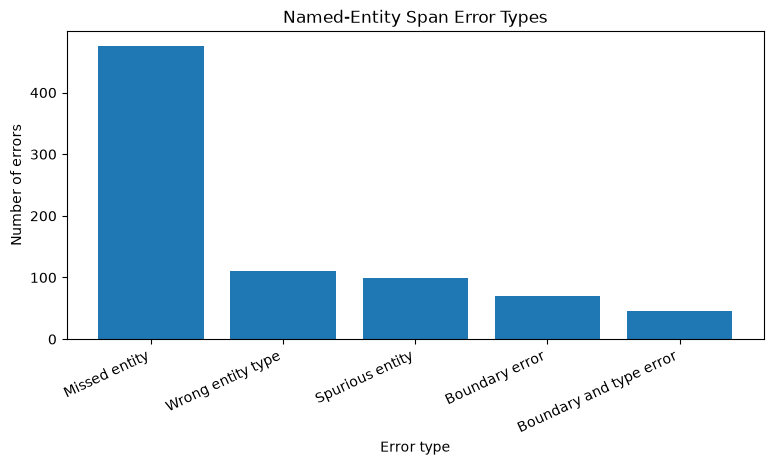

In [40]:
plt.figure(figsize=(9, 4))

plt.bar(
    span_error_summary["error_type"],
    span_error_summary["count"]
)

plt.title("Named-Entity Span Error Types")
plt.xlabel("Error type")
plt.ylabel("Number of errors")
plt.xticks(rotation=25, ha="right")
plt.show()

In [41]:
span_error_df.sample(
    min(15, len(span_error_df)),
    random_state=RANDOM_STATE
)[
    [
        "error_type",
        "true_text",
        "true_type",
        "predicted_text",
        "predicted_type",
        "sentence"
    ]
]

,error_type,true_text,true_type,predicted_text,predicted_type,sentence
697,Boundary error,Valeti Bhabiyan,person,Valeti,person,Now Playing : Apna Sangeet - Valeti Bhabiyan h...
668,Missed entity,iLGDaily,corporation,NaN,NaN,RT @ iLGDaily : https://t.co/ymhWfDRoKm
63,Missed entity,Digeridoo,creative-work,NaN,NaN,"Ah , the ol ' Adelaide [ Digeridoo !"
534,Missed entity,airbnb,corporation,NaN,NaN,"get $ 20 discount when you book in airbnb , us..."
66,Missed entity,BLD,product,NaN,NaN,"Long story short , whats to keep republicans f..."
622,Missed entity,ttuck _ 5,person,NaN,NaN,RT @ ttuck _ 5 : Love the game like Mitch 💰 ht...
346,Missed entity,The Next Three Days,creative-work,NaN,NaN,What is the significance of the torn off butto...
490,Missed entity,Smule,product,NaN,NaN,"Check out "" Yo soy Moana ( Canto ancestral ) ""..."
557,Boundary error,Cheney,person,Cheney Rule,person,@ LegalGeagle I feel like this may turn out to...
456,Spurious entity,NaN,NaN,ThomasBeautyy,person,"RT @ ThomasBeautyy : Do you get assaulted , mu..."


## Span-error analysis 

The error analysis identified 801 entity-span errors:

| Error type | Count | Share |
|---|---:|---:|
| Missed entity | 476 | 59.43% |
| Wrong entity type | 111 | 13.86% |
| Spurious entity | 99 | 12.36% |
| Boundary error | 70 | 8.74% |
| Boundary and type error | 45 | 5.62% |

Missed entities were by far the most common failure, accounting for almost 60% of all analysed errors.

Examples of missed entities included:

- `airbnb` as a corporation
- `The Matrix` as a creative work
- `Smule` as a product
- `republicans` as a group
- unusual usernames labelled as people

Boundary errors occurred when the model identified part of an entity but selected an incomplete or excessive span. For example, it predicted only `Valeti` instead of the complete person name `Valeti Bhabiyan`.

Another example expanded the true person entity `Cheney` into the incorrect span `Cheney Rule`.

The dominance of missed entities agrees with the overall evaluation, where recall was much lower than precision.

In [42]:
confidence_rows = []

for sentence_index, (
    true_labels,
    predicted_labels,
    confidences
) in enumerate(
    zip(
        test_result["true_sequences"],
        test_result[
            "predicted_sequences"
        ],
        test_result[
            "confidence_sequences"
        ]
    )
):
    tokens = raw_dataset["test"][
        sentence_index
    ]["tokens"][:len(true_labels)]

    for (
        token,
        true_label,
        predicted_label,
        confidence
    ) in zip(
        tokens,
        true_labels,
        predicted_labels,
        confidences
    ):
        entity_relevant = (
            true_label != "O"
            or predicted_label != "O"
        )

        if not entity_relevant:
            continue

        confidence_rows.append({
            "token": token,
            "true_label": true_label,
            "predicted_label":
                predicted_label,
            "confidence": confidence,
            "correct":
                true_label
                == predicted_label
        })

confidence_df = pd.DataFrame(
    confidence_rows
)

confidence_df.groupby(
    "correct"
)["confidence"].agg(
    ["mean", "median", "count"]
)

,mean,median,count
correct,,,
False,0.767576,0.863496,1292
True,0.745320,0.821321,569


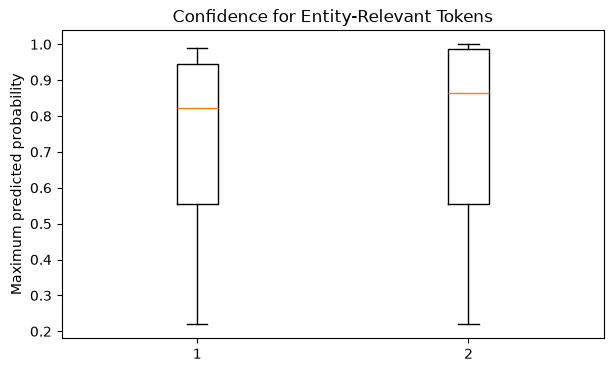

In [44]:
confidence_plot_data = [
    confidence_df.loc[
        confidence_df["correct"],
        "confidence"
    ],
    confidence_df.loc[
        ~confidence_df["correct"],
        "confidence"
    ]
]

plt.figure(figsize=(7, 4))

plt.boxplot(
    confidence_plot_data,
    showfliers=False
)

plt.title(
    "Confidence for Entity-Relevant Tokens"
)

plt.ylabel("Maximum predicted probability")
plt.show()

In [45]:
confidence_df[
    ~confidence_df["correct"]
].sort_values(
    "confidence",
    ascending=False
).head(20)

,token,true_label,predicted_label,confidence,correct
1127,to,I-creative-work,O,0.999687,False
1126,how,I-creative-work,O,0.999646,False
340,they,B-group,O,0.999640,False
341,them,B-group,O,0.999609,False
1629,@,B-person,O,0.999587,False
491,object,I-product,O,0.999561,False
1125,:,I-creative-work,O,0.999554,False
224,u,B-person,O,0.999544,False
1128,start,I-creative-work,O,0.999537,False
253,local,B-creative-work,O,0.999497,False


## Confidence analysis 

Confidence behaved unexpectedly.

For entity-relevant tokens:

| Prediction group | Mean confidence | Median confidence | Count |
|---|---:|---:|---:|
| Correct | 0.7453 | 0.8213 | 569 |
| Incorrect | 0.7676 | 0.8635 | 1,292 |

Incorrect predictions were, on average, slightly more confident than correct predictions.

Many of the most confident errors occurred when the model predicted `O` for a true entity token with confidence above 0.999.

Examples included tokens belonging to:

- creative works
- groups
- products
- people
- corporations

This indicates that the model was not merely uncertain about missed entities. It was often strongly confident that they were not entities.

A simple confidence threshold would therefore not reliably remove the model's errors. The softmax scores were poorly calibrated for entity recognition and should not be interpreted directly as trustworthy probabilities.

In [46]:
lowercase_test_dataset = (
    raw_dataset["test"]
    .map(
        lambda example: {
            "tokens": [
                token.lower()
                for token
                in example["tokens"]
            ]
        }
    )
)

Map:   0%|          | 0/1287 [00:00<?, ? examples/s]

In [47]:
tokenized_lowercase_test = (
    lowercase_test_dataset.map(
        tokenize_and_align_labels,
        batched=True,
        remove_columns=
            lowercase_test_dataset.column_names
    )
)

lowercase_test_loader = DataLoader(
    tokenized_lowercase_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator,
    pin_memory=torch.cuda.is_available()
)

Map:   0%|          | 0/1287 [00:00<?, ? examples/s]

In [48]:
lowercase_result = evaluate_ner_model(
    model,
    lowercase_test_loader
)

casing_comparison_df = pd.DataFrame([
    {
        "condition":
            "Original casing",
        **test_result["metrics"]
    },
    {
        "condition":
            "All lowercase",
        **lowercase_result["metrics"]
    }
])

casing_comparison_df

,condition,precision,recall,f1,token_accuracy,loss
0,Original casing,0.516529,0.348189,0.415973,0.944701,0.275733
1,All lowercase,0.517751,0.162488,0.247350,0.935199,0.375464


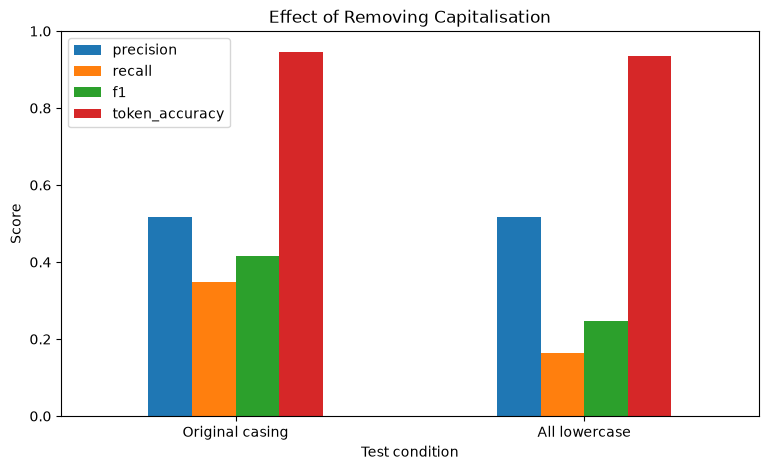

In [49]:
casing_comparison_df.set_index(
    "condition"
)[
    [
        "precision",
        "recall",
        "f1",
        "token_accuracy"
    ]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Effect of Removing Capitalisation")
plt.xlabel("Test condition")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## Casing robustness 

Removing all capitalisation produced the following results:

| Condition | Precision | Recall | F1-score | Token accuracy |
|---|---:|---:|---:|---:|
| Original casing | 0.5165 | 0.3482 | 0.4160 | 0.9447 |
| All lowercase | 0.5178 | 0.1625 | 0.2474 | 0.9352 |

Lowercasing changed precision very little:

- Original precision: 0.5165
- Lowercase precision: 0.5178

However, recall fell sharply:

- Original recall: 0.3482
- Lowercase recall: 0.1625

Entity F1 decreased by approximately 0.1686, representing a relative decline of about 40.5%.

The model therefore relied heavily on capitalisation to decide whether a word belonged to an entity. Without uppercase cues, it predicted substantially fewer entities.

Context and word identity still allowed some correct predictions, but they were not sufficient to preserve the original recall.

In [50]:
from transformers import pipeline

pipeline_device = (
    0 if torch.cuda.is_available()
    else -1
)

ner_pipeline = pipeline(
    task="token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple",
    device=pipeline_device
)

In [51]:
custom_texts = [
    (
        "OpenAI released a new product while "
        "researchers in Brisbane discussed it on GitHub."
    ),
    (
        "Taylor Swift performed in Sydney before "
        "meeting fans from the local music group."
    ),
    (
        "I finally bought a PlayStation 5 from Sony yesterday."
    )
]

for text in custom_texts:
    print("=" * 80)
    print(text)

    entities = ner_pipeline(text)

    display(
        pd.DataFrame(entities)
    )

OpenAI released a new product while researchers in Brisbane discussed it on GitHub.


,entity_group,score,word,start,end
0,corporation,0.518022,Open,0,4
1,corporation,0.181009,##A,4,5
2,location,0.946153,Brisbane,51,59
3,corporation,0.681121,G,76,77


Taylor Swift performed in Sydney before meeting fans from the local music group.


,entity_group,score,word,start,end
0,person,0.942903,Taylor Swift,0,12
1,location,0.977242,Sydney,26,32


I finally bought a PlayStation 5 from Sony yesterday.


,entity_group,score,word,start,end
0,product,0.673113,PlayStation,19,30
1,corporation,0.490050,Sony,38,42


## Custom inference 

The custom examples produced mixed results.

### Example 1

`OpenAI released a new product while researchers in Brisbane discussed it on GitHub.`

The model correctly identified:

- `Brisbane` as a location

However:

- `OpenAI` was split into incomplete subword predictions rather than one clean entity
- `GitHub` was reduced to only the initial `G`
- the corporation predictions had relatively low confidence

This demonstrates a weakness with compound names and entities that were uncommon or absent from the training domain.

### Example 2

`Taylor Swift performed in Sydney before meeting fans from the local music group.`

The model correctly extracted:

- `Taylor Swift` as a person
- `Sydney` as a location

Both predictions had high confidence and correct multi-word boundaries.

### Example 3

`I finally bought a PlayStation 5 from Sony yesterday.`

The model extracted:

- `PlayStation` as a product
- `Sony` as a corporation

However, it omitted `5` from the complete product name `PlayStation 5`.

Overall, the model handled familiar person and location names more reliably than newer corporations, products, and compound technology names. The custom results were consistent with the test evaluation, where person and location were the strongest categories and product and corporation were the weakest.